# KYC analysis and improvement

Analysis of the declining KYC pass rate: what is driving it and what can be done about it.

1. Exploratory data analysis
2. Data preparation
3. KYC result analysis
4. Users with multiple attempts
5. Conclusions and recommendations

### Import packages

In [1]:
import numpy as np
import pandas as pd
import ast # For converting string like data to dict

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

In [2]:
# Import files
doc_report = pd.read_csv('data/doc_report.csv')
facial_report = pd.read_csv('data/facial_similarity_report.csv')

## 1 Exploratory data analysis
### 1.1 Explore document report

In [3]:
doc_report.head()

,number,user_id,result,visual_authenticity_result,image_integrity_result,face_detection_result,image_quality_result,created_at,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,attempt_id,police_record_result,compromised_document_result,properties,sub_result
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,consider,consider,clear,clear,clear,2017-06-20T23:12:57Z,clear,NaN,NaN,clear,clear,NaN,050a0596de424fab83c433eaa18b3f8d,clear,NaN,"{'gender': 'Male', 'nationality': 'IRL', 'docu...",caution
1,1,15a84e8951254011b47412fa4e8f65b8,clear,clear,clear,clear,clear,2017-06-20T23:16:04Z,clear,NaN,NaN,clear,NaN,NaN,f69c1e5f45a64e50a26740b9bfb978b7,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear
2,2,ffb82fda52b041e4b9af9cb4ef298c85,clear,clear,clear,clear,clear,2017-06-20T17:59:49Z,clear,NaN,NaN,clear,clear,NaN,f9f84f3055714d8e8f7419dc984d1769,clear,NaN,"{'gender': 'Male', 'nationality': 'ITA', 'docu...",clear
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,clear,clear,clear,clear,clear,2017-06-20T17:59:38Z,clear,NaN,NaN,clear,clear,NaN,10a54a1ecf794404be959e030f11fef6,clear,NaN,"{'gender': 'Male', 'issuing_date': '2007-08', ...",clear
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,clear,clear,clear,clear,clear,2017-06-20T18:08:09Z,clear,NaN,NaN,clear,clear,NaN,1f320d1d07de493292b7e0d5ebfb1cb9,clear,NaN,"{'gender': 'Male', 'nationality': 'POL', 'docu...",clear


In [4]:
doc_report.info()

<class 'pandas.DataFrame'>
RangeIndex: 176404 entries, 0 to 176403
Data columns (total 19 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   number                              176404 non-null  int64
 1   user_id                             176404 non-null  str  
 2   result                              176404 non-null  str  
 3   visual_authenticity_result          150290 non-null  str  
 4   image_integrity_result              176403 non-null  str  
 5   face_detection_result               150261 non-null  str  
 6   image_quality_result                176403 non-null  str  
 7   created_at                          176404 non-null  str  
 8   supported_document_result           175900 non-null  str  
 9   conclusive_document_quality_result  95217 non-null   str  
 10  colour_picture_result               95222 non-null   str  
 11  data_validation_result              142974 non-null  str  
 12 

#### Initial findings:
- Properties column contains dict like data with document details (type, issuing country, expiry date etc.)
- Date type needs to be changed for created_at
- Some check columns have many missing values (e.g. conclusive_document_quality_result): need to check if these checks were only introduced later

In [5]:
# Avoid issues with large numeric IDs
doc_report['user_id'] = doc_report['user_id'].astype(str)
doc_report['attempt_id'] = doc_report['attempt_id'].astype(str)

# Convert created_at to date
doc_report['created_at'] = pd.to_datetime(doc_report['created_at']).dt.tz_localize(None)

#### Extract doc check report properties
Create a new column for each property

In [6]:
# Handling strings that look like dicts
doc_report['properties'] = doc_report['properties'].apply(ast.literal_eval) # Only parses safe Python literals

# Flatten the dict column
doc_expanded = pd.DataFrame(doc_report['properties'].tolist())
doc_expanded.head()

,gender,nationality,document_type,date_of_expiry,issuing_country,issuing_date,issuing_state,document_version
0,Male,IRL,passport,2019-08-12,IRL,NaN,NaN,NaN
1,Female,NaN,driving_licence,2023-02-28,GBR,NaN,NaN,NaN
2,Male,ITA,passport,2018-06-09,ITA,NaN,NaN,NaN
3,Male,NaN,national_identity_card,NaN,FRA,2007-08,NaN,NaN
4,Male,POL,national_identity_card,2019-05-29,POL,NaN,NaN,NaN


In [7]:
# Convert dates
doc_expanded['date_of_expiry'] = pd.to_datetime(doc_expanded['date_of_expiry'], errors='coerce')
doc_expanded['issuing_date'] = pd.to_datetime(doc_expanded['issuing_date'], errors='coerce')

# Add properties to the document report
doc_report = pd.concat([doc_report.drop(columns='properties'), doc_expanded], axis=1)

### 1.2 Explore facial similarity report

In [8]:
facial_report.head()

,number,user_id,result,face_comparison_result,created_at,facial_image_integrity_result,visual_authenticity_result,properties,attempt_id
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,clear,clear,2017-06-20T23:12:58Z,clear,consider,{},050a0596de424fab83c433eaa18b3f8d
1,1,15a84e8951254011b47412fa4e8f65b8,clear,clear,2017-06-20T23:16:04Z,clear,clear,{},f69c1e5f45a64e50a26740b9bfb978b7
2,2,ffb82fda52b041e4b9af9cb4ef298c85,clear,clear,2017-06-20T17:59:49Z,clear,clear,{},f9f84f3055714d8e8f7419dc984d1769
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,clear,clear,2017-06-20T17:59:39Z,clear,clear,{},10a54a1ecf794404be959e030f11fef6
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,clear,clear,2017-06-20T18:08:09Z,clear,clear,{},1f320d1d07de493292b7e0d5ebfb1cb9


In [9]:
facial_report.info()

<class 'pandas.DataFrame'>
RangeIndex: 176404 entries, 0 to 176403
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype
---  ------                         --------------   -----
 0   number                         176404 non-null  int64
 1   user_id                        176404 non-null  str  
 2   result                         176403 non-null  str  
 3   face_comparison_result         166007 non-null  str  
 4   created_at                     176404 non-null  str  
 5   facial_image_integrity_result  175941 non-null  str  
 6   visual_authenticity_result     150290 non-null  str  
 7   properties                     176404 non-null  str  
 8   attempt_id                     176404 non-null  str  
dtypes: int64(1), str(8)
memory usage: 12.1 MB


In [10]:
# Check properties column: we suspect it mostly contains {}
facial_report['properties'].value_counts(normalize=True).head()

properties
{}                 0.980256
{'score': 0.69}    0.000958
{'score': 0.64}    0.000924
{'score': 0.63}    0.000901
{'score': 0.66}    0.000901
Name: proportion, dtype: float64

##### Initial findings:
- Properties is empty for ~98% of rows (the rest only hold a similarity score), not needed for this analysis
- visual_authenticity_result is also in the document report, check if it is a duplicate

In [11]:
facial_report['user_id'] = facial_report['user_id'].astype(str)
facial_report['attempt_id'] = facial_report['attempt_id'].astype(str)
facial_report['created_at'] = pd.to_datetime(facial_report['created_at']).dt.tz_localize(None)

In [12]:
# Compare visual authenticity results in the two tables (same order of attempts in both files)
(doc_report['attempt_id'] == facial_report['attempt_id']).all(), doc_report['visual_authenticity_result'].equals(facial_report['visual_authenticity_result'])

(np.True_, True)

In [13]:
# Duplicate column and properties not needed
facial_report = facial_report.drop(columns=['properties', 'visual_authenticity_result'])

## 2 Data preparation
#### Merging document and facial check results

In [14]:
doc_report_subset = doc_report.rename(columns={
    'result': 'doc_result',
    'sub_result': 'doc_sub_result',
    'created_at': 'doc_created_at'
})

facial_report_subset = facial_report.drop(columns='number').rename(columns={
    'result': 'facial_result',
    'created_at': 'facial_created_at'
})

In [15]:
# validate checks there is only one row per attempt in each table
combined_check_results = doc_report_subset.merge(facial_report_subset, on=['user_id', 'attempt_id'], how='left', validate='one_to_one', indicator=True)
combined_check_results['_merge'].value_counts()

_merge
both          176404
left_only          0
right_only         0
Name: count, dtype: int64

In [16]:
# All attempts matched
combined_check_results = combined_check_results.drop(columns='_merge')

#### Adding check results as numeric values
Coding pass/fail results as 1/0 to make the analysis easier

In [17]:
combined_check_results['doc_check_fail'] = (combined_check_results['doc_result'] != 'clear').astype(int)
combined_check_results['facial_check_fail'] = (combined_check_results['facial_result'] != 'clear').astype(int)

combined_check_results['failed_both_checks'] = combined_check_results['doc_check_fail'] * combined_check_results['facial_check_fail']
combined_check_results['only_doc_check_fail'] = combined_check_results['doc_check_fail'] - combined_check_results['failed_both_checks']
combined_check_results['only_facial_check_fail'] = combined_check_results['facial_check_fail'] - combined_check_results['failed_both_checks']

# User passed KYC if both checks are clear
combined_check_results['kyc_pass'] = 1 - (combined_check_results['doc_check_fail'] | combined_check_results['facial_check_fail'])

In [18]:
# Date and week columns for analysis over time
combined_check_results['doc_created_date'] = combined_check_results['doc_created_at'].dt.normalize()
combined_check_results['week'] = combined_check_results['doc_created_at'].dt.to_period('W').dt.start_time

#### Order of attempts at user level

Originally I used the `number` column to order each user's attempts, but it turns out it's not in time order:

In [19]:
# Share of rows where the next number has an earlier timestamp
(combined_check_results.sort_values('number')['doc_created_at'].diff().dt.total_seconds() < 0).mean()

np.float64(0.27193260923788576)

In [20]:
# ~27% go backwards in time, so order by timestamp instead (number only as tie-breaker)
combined_check_results = combined_check_results.sort_values(['user_id', 'doc_created_at', 'number']).reset_index(drop=True)

combined_check_results['user_id_count'] = combined_check_results.groupby('user_id')['user_id'].transform('count')
combined_check_results['order'] = combined_check_results.groupby('user_id').cumcount() + 1

In [21]:
# Flag checks which were not necessary because the user already passed in an earlier attempt
combined_check_results['previous_kyc'] = combined_check_results.groupby('user_id')['kyc_pass'].shift(1, fill_value=0)
combined_check_results['has_previous_pass'] = combined_check_results.groupby('user_id')['previous_kyc'].cummax()
combined_check_results['necessary_check'] = 1 - combined_check_results['has_previous_pass']

combined_check_results['necessary_check'].value_counts()

necessary_check
1    170616
0      5788
Name: count, dtype: int64

#### Data gap
Checking daily volumes, there is a gap around 19-21 October (almost no checks). Probably an issue with the data extract, need to keep in mind when looking at October.

In [22]:
daily_checks = combined_check_results.groupby('doc_created_date').size()
daily_checks['2017-10-16':'2017-10-23']

doc_created_date
2017-10-16    2257
2017-10-17    2234
2017-10-18    2618
2017-10-20       2
2017-10-21       3
2017-10-22     322
2017-10-23    1858
dtype: int64

## 3 KYC result analysis
### 3.1 Users with necessary checks
Only consider checks that were needed (exclude checks after the user already passed)

In [23]:
required_tests = combined_check_results[combined_check_results['necessary_check'] == 1]

In [24]:
kyc_analysis = {
    'unique_users': [required_tests['user_id'].nunique()],
    'users_passed': [required_tests[required_tests['kyc_pass'] == 1]['user_id'].nunique()],
    'total_check_count': [len(required_tests)],
    'failed_check_count': [(required_tests['kyc_pass'] == 0).sum()],
    'only_doc_check_failed': [required_tests['only_doc_check_fail'].sum()],
    'only_facial_check_failed': [required_tests['only_facial_check_fail'].sum()],
    'failed_both_checks': [required_tests['failed_both_checks'].sum()]
}

kyc_analysis_df = pd.DataFrame(kyc_analysis)
kyc_analysis_df['pass_rate'] = kyc_analysis_df['users_passed'] / kyc_analysis_df['unique_users']
kyc_analysis_df

,unique_users,users_passed,total_check_count,failed_check_count,only_doc_check_failed,only_facial_check_failed,failed_both_checks,pass_rate
0,142724,121447,170616,49169,38358,5442,5369,0.850922


In [25]:
# Share of failed checks by cause
kyc_analysis_df[['only_doc_check_failed', 'only_facial_check_failed', 'failed_both_checks']] / kyc_analysis_df['failed_check_count'][0]

,only_doc_check_failed,only_facial_check_failed,failed_both_checks
0,0.780126,0.110679,0.109195


#### KYC pass rate over time

I tested a few definitions:
- Pass rate per check: penalises users who retry, so understates the pass rate
- Pass rate per user per day: a user who retries on a different day is counted twice
- **Pass rate per user, grouped by week of first attempt (used below):** each user counted once, and "passed" means passed in any attempt. This matches the definition in the problem statement

Note: users in the last week had less time to retry so the last data point is less reliable.

In [26]:
user_results = combined_check_results.groupby('user_id').agg(
    first_attempt=('doc_created_at', 'min'),
    attempts=('order', 'max'),
    passed=('kyc_pass', 'max')
)
user_results['first_week'] = user_results['first_attempt'].dt.to_period('W').dt.start_time

pass_rate_by_week = user_results.groupby('first_week').agg(
    unique_users=('passed', 'count'),
    pass_rate=('passed', 'mean')
).reset_index()
pass_rate_by_week

,first_week,unique_users,pass_rate
0,2017-05-22,906,0.850993
1,2017-05-29,1300,0.821538
2,2017-06-05,1068,0.893258
3,2017-06-12,948,0.968354
4,2017-06-19,2209,0.968764
5,2017-06-26,3253,0.962496
6,2017-07-03,5212,0.967383
7,2017-07-10,6474,0.926784
8,2017-07-17,7628,0.922522
9,2017-07-24,7784,0.916624


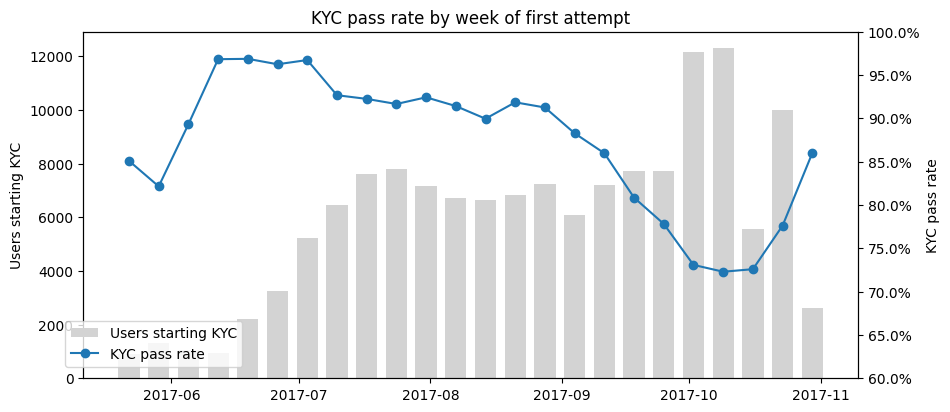

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(pass_rate_by_week['first_week'], pass_rate_by_week['unique_users'], width=5, color='lightgrey', label='Users starting KYC')
ax1.set_ylabel('Users starting KYC')

ax2 = ax1.twinx()
ax2.plot(pass_rate_by_week['first_week'], pass_rate_by_week['pass_rate'], marker='o', label='KYC pass rate')
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
ax2.set_ylim(0.6, 1)
ax2.set_ylabel('KYC pass rate')

plt.title('KYC pass rate by week of first attempt')
fig.legend(loc='lower left', bbox_to_anchor=(0.1, 0.12))
plt.savefig('images/pass_rate_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

Pass rate was ~97% from mid June to early July, then dropped in two steps (mid July and mid September) to ~72% in early October. Partial recovery at the end of October.

### 3.2 Drivers of failed KYC

In [28]:
weekly_results = required_tests.groupby('week').agg(
    total_check_count=('kyc_pass', 'count'),
    doc_check_fail=('doc_check_fail', 'mean'),
    facial_check_fail=('facial_check_fail', 'mean')
).reset_index()

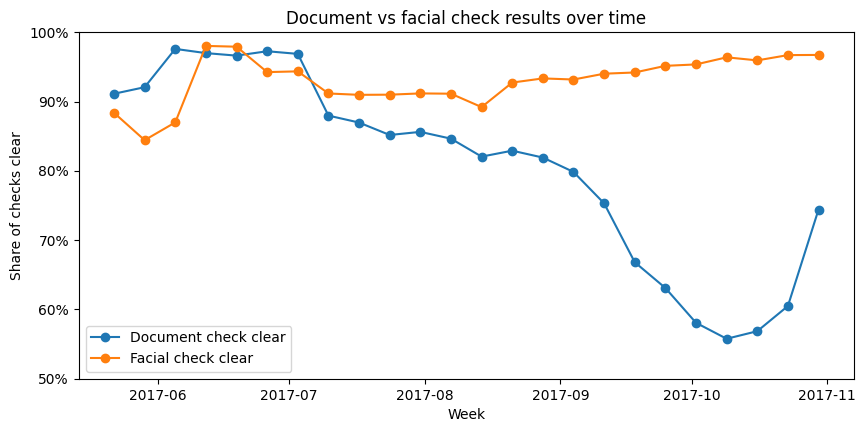

In [29]:
plt.figure(figsize=(10, 4.5))
plt.plot(weekly_results['week'], 1 - weekly_results['doc_check_fail'], marker='o', label='Document check clear')
plt.plot(weekly_results['week'], 1 - weekly_results['facial_check_fail'], marker='o', label='Facial check clear')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.ylim(0.5, 1)
plt.xlabel('Week')
plt.ylabel('Share of checks clear')
plt.title('Document vs facial check results over time')
plt.legend()
plt.savefig('images/doc_vs_facial.png', dpi=150, bbox_inches='tight')
plt.show()

~78% of failed checks fail on the document check only. The document check gets worse from July while the facial check actually improves, so the deep dive focuses on document checks.

#### Deep dive into failed document checks
Analysis of document check sub-results to identify drivers

In [30]:
doc_check_summary = required_tests['doc_sub_result'].value_counts().reset_index(name='count')
doc_check_summary['percentage'] = doc_check_summary['count'] / doc_check_summary['count'].sum()
doc_check_summary

,doc_sub_result,count,percentage
0,clear,126889,0.743711
1,rejected,25905,0.151832
2,caution,15921,0.093315
3,suspected,1901,0.011142


In [31]:
# Document check sub-result over time (7 day rolling average, excluding the days in the data gap)
doc_sub_result = required_tests.groupby('doc_created_date').agg(
    total_checks=('doc_sub_result', 'count'),
    rejected=('doc_sub_result', lambda x: (x == 'rejected').mean()),
    caution=('doc_sub_result', lambda x: (x == 'caution').mean()),
    suspected=('doc_sub_result', lambda x: (x == 'suspected').mean())
)
doc_sub_result = doc_sub_result[doc_sub_result['total_checks'] >= 100]
doc_sub_result_rolling = doc_sub_result[['rejected', 'caution', 'suspected']].rolling(7).mean()

In [32]:
# When did each sub-result increase? First day above 5% of checks
rejected_start = doc_sub_result[doc_sub_result['rejected'] > 0.05].index.min()
caution_start = doc_sub_result.loc['2017-08-01':][doc_sub_result.loc['2017-08-01':, 'caution'] > 0.05].index.min()
caution_end = doc_sub_result.loc['2017-10-15':][doc_sub_result.loc['2017-10-15':, 'caution'] < 0.05].index.min()

rejected_start, caution_start, caution_end

(Timestamp('2017-07-11 00:00:00'),
 Timestamp('2017-09-14 00:00:00'),
 Timestamp('2017-10-29 00:00:00'))

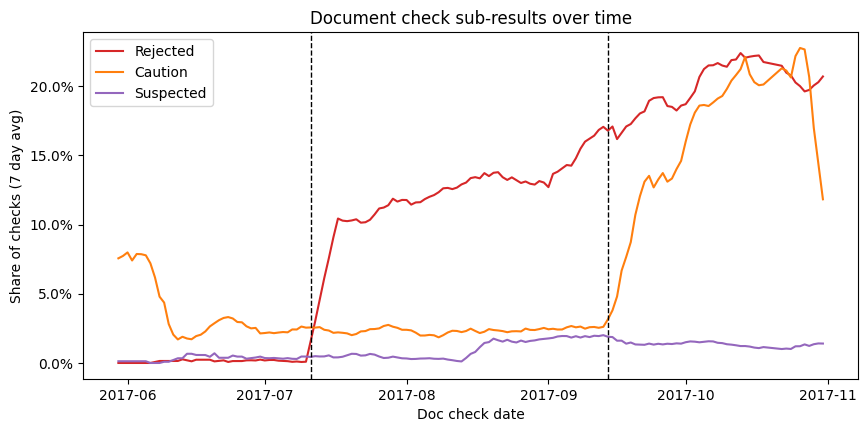

In [33]:
plt.figure(figsize=(10, 4.5))
plt.plot(doc_sub_result_rolling.index, doc_sub_result_rolling['rejected'], label='Rejected', color='tab:red')
plt.plot(doc_sub_result_rolling.index, doc_sub_result_rolling['caution'], label='Caution', color='tab:orange')
plt.plot(doc_sub_result_rolling.index, doc_sub_result_rolling['suspected'], label='Suspected', color='tab:purple')
plt.axvline(rejected_start, color='black', linestyle='--', linewidth=1)
plt.axvline(caution_start, color='black', linestyle='--', linewidth=1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xlabel('Doc check date')
plt.ylabel('Share of checks (7 day avg)')
plt.title('Document check sub-results over time')
plt.legend()
plt.savefig('images/doc_failure_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

Two separate changes:
- **Rejected** appears from 11 July and keeps increasing to ~21% of checks
- **Caution** jumps from ~2% to ~21% between mid September and the end of October, then drops back

#### Analysis of users with rejected document check sub-result

In [34]:
rejected_doc_result = required_tests[required_tests['doc_sub_result'] == 'rejected']
len(rejected_doc_result)

25905

In [35]:
# Columns to check: document check sub-result is driven by these columns based on KYC process description
cols_to_check = ['image_quality_result', 'supported_document_result', 'conclusive_document_quality_result', 'colour_picture_result']

iir_analysis = pd.DataFrame({
    col: rejected_doc_result[col].value_counts(dropna=False)
    for col in cols_to_check
})
iir_analysis

,image_quality_result,supported_document_result,conclusive_document_quality_result,colour_picture_result
clear,1634.0,23773,NaN,NaN
unidentified,24271.0,1634,NaN,NaN
NaN,NaN,498,25905.0,25905.0


In [36]:
# Were document details extracted for rejected checks?
rejected_doc_result['document_type'].isna().mean()

np.float64(0.9996525767226404)

~94% of rejected checks have image quality "unidentified" and no document type was extracted for any of them. So these are not fake documents, the image could not be read at all. Since it starts suddenly on one day, it looks like something changed in the app / photo capture or the vendor settings.

#### Analysis of users with caution document check sub-result

In [37]:
caution_doc_result = required_tests[required_tests['doc_sub_result'] == 'caution']
len(caution_doc_result)

15921

In [38]:
cols_to_check = ['image_integrity_result', 'conclusive_document_quality_result', 'visual_authenticity_result',
                 'data_validation_result', 'face_detection_result']

caution_analysis = pd.DataFrame({
    col: caution_doc_result[col].value_counts(dropna=False, normalize=True)
    for col in cols_to_check
})
caution_analysis

,image_integrity_result,conclusive_document_quality_result,visual_authenticity_result,data_validation_result,face_detection_result
clear,0.158282,0.069908,0.909553,0.899253,0.964198
consider,0.841718,0.838515,0.089128,0.075247,0.034294
NaN,NaN,0.091577,0.001319,0.025501,0.001507


In [39]:
# conclusive_document_quality_result is missing for the first months: when was it introduced?
conclusive_quality = required_tests.groupby('week').agg(
    check_present=('conclusive_document_quality_result', lambda x: x.notna().mean()),
    consider=('conclusive_document_quality_result', lambda x: (x == 'consider').mean()),
    caution=('doc_sub_result', lambda x: (x == 'caution').mean())
).reset_index()

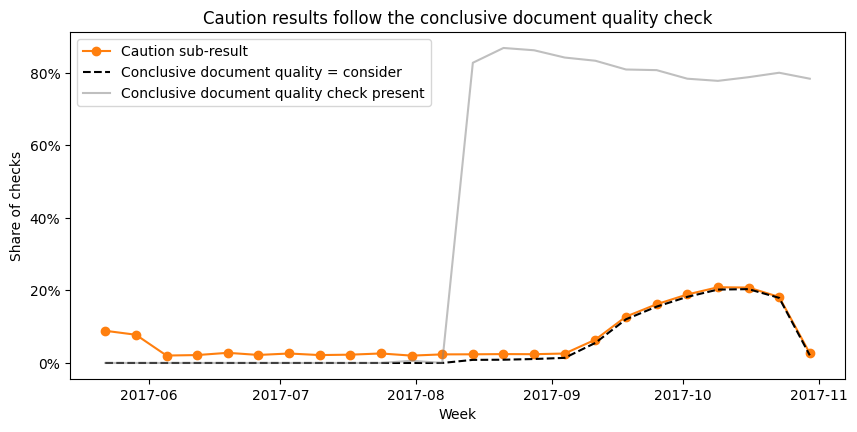

In [40]:
plt.figure(figsize=(10, 4.5))
plt.plot(conclusive_quality['week'], conclusive_quality['caution'], marker='o', label='Caution sub-result', color='tab:orange')
plt.plot(conclusive_quality['week'], conclusive_quality['consider'], linestyle='--', color='black', label='Conclusive document quality = consider')
plt.plot(conclusive_quality['week'], conclusive_quality['check_present'], color='grey', alpha=0.5, label='Conclusive document quality check present')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.xlabel('Week')
plt.ylabel('Share of checks')
plt.title('Caution results follow the conclusive document quality check')
plt.legend()
plt.savefig('images/caution_driver.png', dpi=150, bbox_inches='tight')
plt.show()

The conclusive document quality check starts in mid August. It rarely flags anything at first, but from mid September it flags more and more checks and the caution rate follows it almost exactly (~84% of caution results have it at "consider"). The sudden drop at the end of October suggests the rule was fixed.

#### Results by document type and issuing country (before vs during the caution increase)

In [41]:
document_analysis_before = required_tests[(required_tests['doc_created_at'] >= '2017-07-10') & (required_tests['doc_created_at'] < caution_start)]
document_analysis_during = required_tests[(required_tests['doc_created_at'] >= caution_start) & (required_tests['doc_created_at'] < caution_end)]

In [42]:
doc_type_results = pd.DataFrame({
    'checks_before': document_analysis_before.groupby('document_type').size(),
    'caution_pct_before': document_analysis_before.groupby('document_type')['doc_sub_result'].apply(lambda x: (x == 'caution').mean()),
    'checks_during': document_analysis_during.groupby('document_type').size(),
    'caution_pct_during': document_analysis_during.groupby('document_type')['doc_sub_result'].apply(lambda x: (x == 'caution').mean())
})
doc_type_results[doc_type_results['checks_during'] >= 1000].sort_values('caution_pct_during', ascending=False)

,checks_before,caution_pct_before,checks_during,caution_pct_during
document_type,,,,
passport,19517,0.032177,15622.0,0.338561
driving_licence,21378,0.031107,20163.0,0.225611
residence_permit,1385,0.043321,1066.0,0.160413
national_identity_card,23708,0.018264,22771.0,0.152211


In [43]:
issuing_country_results = pd.DataFrame({
    'checks_before': document_analysis_before.groupby('issuing_country').size(),
    'caution_pct_before': document_analysis_before.groupby('issuing_country')['doc_sub_result'].apply(lambda x: (x == 'caution').mean()),
    'checks_during': document_analysis_during.groupby('issuing_country').size(),
    'caution_pct_during': document_analysis_during.groupby('issuing_country')['doc_sub_result'].apply(lambda x: (x == 'caution').mean())
})
issuing_country_results[issuing_country_results['checks_during'] >= 1000].sort_values('caution_pct_during', ascending=False).head(10)

,checks_before,caution_pct_before,checks_during,caution_pct_during
issuing_country,,,,
GBR,17111.0,0.028578,14710.0,0.342420
IRL,4227.0,0.026969,3608.0,0.286308
PRT,2681.0,0.027229,2045.0,0.230318
ITA,1937.0,0.060919,2199.0,0.207822
ESP,4846.0,0.022286,3142.0,0.200509
DEU,1771.0,0.030491,2075.0,0.195663
FRA,10624.0,0.022402,9530.0,0.181532
POL,3865.0,0.021475,3766.0,0.167286
LTU,3648.0,0.024397,7542.0,0.159242


#### Users with expired documents

In [44]:
required_tests = required_tests.copy()
required_tests['expired_document'] = (required_tests['date_of_expiry'].notna() & (required_tests['doc_created_at'] >= required_tests['date_of_expiry'])).astype(int)

# Share of expired documents in caution checks
required_tests[required_tests['doc_sub_result'] == 'caution']['expired_document'].mean()

np.float64(0.07455561836568055)

All document types and countries were affected but passports and UK documents the most (~34% caution, up from ~3%). Expired documents are only ~7% of caution results so not a main driver.

### 3.3 What happened to users who never passed?

In [45]:
# Last attempt of users who never passed KYC
last_attempt = combined_check_results.groupby('user_id').tail(1)
never_passed = last_attempt[last_attempt['user_id'].isin(user_results[user_results['passed'] == 0].index)]

len(never_passed), never_passed['doc_sub_result'].value_counts(normalize=True)

(21277,
 doc_sub_result
 rejected     0.506368
 caution      0.345161
 clear        0.103539
 suspected    0.044931
 Name: proportion, dtype: float64)

In [46]:
# Pass rate of users who got at least one rejected result vs everyone else
user_results['ever_rejected'] = combined_check_results.groupby('user_id')['doc_sub_result'].apply(lambda x: (x == 'rejected').any())
user_results.groupby('ever_rejected')['passed'].agg(['count', 'mean'])

,count,mean
ever_rejected,,
False,124301,0.928577
True,18423,0.326983


For ~85% of users who never passed, the last attempt was rejected (51%) or caution (35%). Users who got a rejected result only passed in ~33% of cases vs ~93% for everyone else, so many users give up after a rejected result.

## 4 Analysis of users with multiple attempts

In [47]:
multiple_tries = combined_check_results[combined_check_results['user_id_count'] > 1]

summary = {
    'unique_users': [multiple_tries['user_id'].nunique()],
    'total_attempts': [len(multiple_tries)],
    'users_with_unnecessary_checks': [multiple_tries[multiple_tries['necessary_check'] == 0]['user_id'].nunique()],
    'unnecessary_checks': [(multiple_tries['necessary_check'] == 0).sum()]
}

summary_df = pd.DataFrame(summary)
summary_df['pct_of_all_checks'] = summary_df['unnecessary_checks'] / len(combined_check_results)
summary_df

,unique_users,total_attempts,users_with_unnecessary_checks,unnecessary_checks,pct_of_all_checks
0,32350,66030,5320,5788,0.032811


5,788 checks (3.3% of all checks) were done by users who had already passed KYC. These checks are not needed and each costs a verification fee.

Note: my first version ordered attempts by `number` and got ~9,700 unnecessary checks. With the correct order by timestamp it is 5,788.

## 5 Conclusions and recommendations

**Conclusions**
- KYC pass rate dropped from ~97% (mid June to early July) to ~72% (early October)
- The document check is the main driver (~78% of failed checks), the facial check improved over the same period
- Two separate issues in the document check:
    1. From 11 July: more and more images can't be read at all (rejected), up to ~21% of checks
    2. Mid September to end of October: the new conclusive document quality check flagged up to ~21% of checks as caution, mostly passports and UK documents
- Users who get a rejected result often don't come back (only ~33% eventually pass)
- 5,788 checks were done after the user had already passed

**Recommendations**
1. Find out what changed around 11 July (app release, photo capture flow, vendor settings)
2. Check image quality in the app before upload (blur, glare, document in frame) so users can retake the photo straight away
3. Confirm with the vendor what changed with the conclusive document quality check and set up monitoring of caution rates by document type / country, so a problem like this is caught in days, not weeks
4. Don't allow new KYC submissions once a user has passed

**Next steps:** estimate the impact of each fix (users recovered and verification cost saved) and check the root causes against the app release log.